<a href="https://colab.research.google.com/github/Tiruvadhi-Chiruhasini/CodeAlpha_Credit_Risk_Prediction/blob/main/Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Loading Credit Scoring Dataset...
Dataset Shape: (1000, 21)
2. Performing Feature Engineering & Preprocessing...
3. Training Machine Learning Models...

=== Model Performance Evaluation ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.745     0.7665  0.9143    0.8339   0.7600
      Decision Tree     0.685     0.7200  0.9000    0.8000   0.6893
      Random Forest     0.745     0.7543  0.9429    0.8381   0.7675


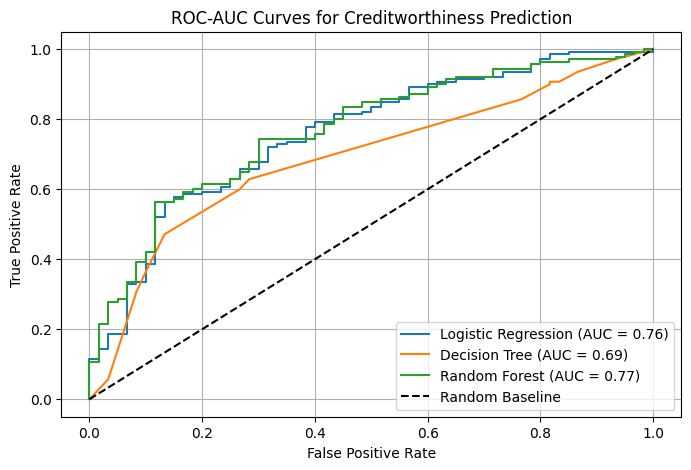

Execution complete! You can download 'roc_auc_plot.png' directly from Colab files.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve

print("1. Loading Credit Scoring Dataset...")
# Public dataset directly loaded via raw URL (German Credit Dataset)
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")

# Target variable definition (1 = Good Credit, 0 = Bad Credit)
# If target is 1/2 in GermanCredit, re-map to 1/0
if 'default' in df.columns:
    target_col = 'default'
else:
    target_col = df.columns[-1]

# Feature Engineering & Preprocessing
print("2. Performing Feature Engineering & Preprocessing...")

# Handle categorical variables using Label Encoding
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Create engineered features (e.g., Credit-to-Age Ratio, Payment installment ratio)
if 'Amount' in df.columns and 'Age' in df.columns:
    df['Credit_Per_Age'] = df['Amount'] / (df['Age'] + 1)
if 'Amount' in df.columns and 'Duration' in df.columns:
    df['Monthly_Installment_Est'] = df['Amount'] / (df['Duration'] + 1)

# Features and Target split
X = df.drop(columns=[target_col])
y = df[target_col]

# Handle target binary encoding if necessary
if y.min() == 1 and y.max() == 2:
    y = y.map({1: 1, 2: 0}) # 1 = Good, 0 = Default/Bad

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("3. Training Machine Learning Models...")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
}

results = []

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

# Convert evaluation results to DataFrame
results_df = pd.DataFrame(results)
print("\n=== Model Performance Evaluation ===")
print(results_df.to_string(index=False))

# Plot ROC Curves
plt.figure(figsize=(8, 5))
for name, model in models.items():
    if name == "Logistic Regression":
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves for Creditworthiness Prediction")
plt.legend()
plt.grid(True)
plt.savefig("roc_auc_plot.png")
plt.show()

print("Execution complete! You can download 'roc_auc_plot.png' directly from Colab files.")